## 1. Importando bibliotecas
---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## 2. Configuração de caminhos

In [37]:
path_commodity = r'C:\Users\lucas.takabayashi\Desktop\GitHub\agro-analysis\data\clean\commodities.xlsx'
path_producao = r'C:\Users\lucas.takabayashi\Desktop\GitHub\agro-analysis\data\clean\producao_agricola.xlsx'

In [38]:
df_commodity = pd.read_excel(path_commodity)
df_producao = pd.read_excel(path_producao)

In [21]:
df_commodity.head()

,data,ano,mes,ano_mes,dolar,soja_scs,milho_scs,soja_scs_var,milho_scs_var,dolar_var
0,2020-01-02,2020,1,2020-01,4.02,82.92,48.43,NaN,NaN,NaN
1,2020-01-03,2020,1,2020-01,4.05,83.01,48.91,0.11,0.99,0.75
2,2020-01-06,2020,1,2020-01,4.07,82.83,48.99,-0.22,0.16,0.49
3,2020-01-07,2020,1,2020-01,4.06,82.81,49.31,-0.02,0.65,-0.25
4,2020-01-08,2020,1,2020-01,4.05,82.95,50.26,0.17,1.93,-0.25


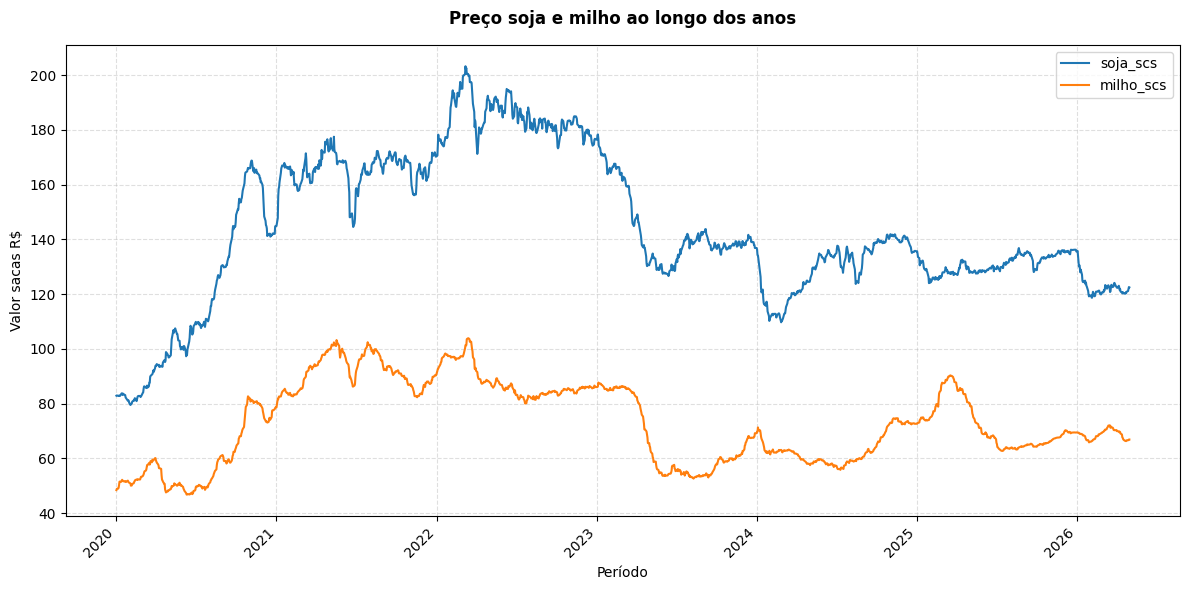

In [91]:
features = ['soja_scs','milho_scs']

plt.figure(figsize=(12,6))
for col in features:
    sns.lineplot(
    data=df_commodity, 
    x="data", 
    y=col, 
    label=col,
    linewidth=1.5)

plt.title('Preço soja e milho ao longo dos anos', fontweight='bold', pad=15)
plt.xlabel('Período')
plt.ylabel('Valor sacas R$')
plt.xticks(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()

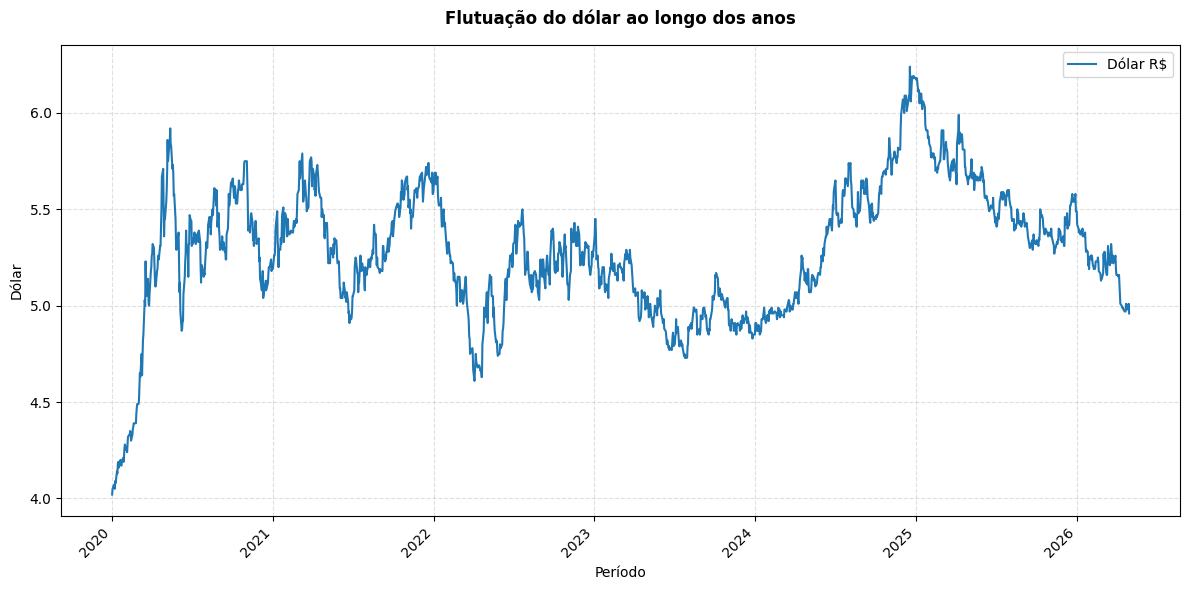

In [90]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_commodity, 
    x="data", 
    y='dolar', 
    label='Dólar R$',
    linewidth=1.5)

plt.title('Flutuação do dólar ao longo dos anos', fontweight='bold', pad=15)
plt.xlabel('Período')
plt.ylabel('Dólar')
plt.xticks(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()

In [39]:
df_producao.head()

,estado,ano_mes,area_plantada_hect,area_colhida_hect,producao_toneladas,rendimento_kg_por_hect,commodity,data
0,Sao Paulo,janeiro 2020,1105360,1105300,3659600,3311,soja,2020-01
1,Sao Paulo,fevereiro 2020,1105360,1105300,3659600,3311,soja,2020-02
2,Sao Paulo,março 2020,1105360,1105300,3659600,3311,soja,2020-03
3,Sao Paulo,abril 2020,1105360,1105300,3659600,3311,soja,2020-04
4,Sao Paulo,maio 2020,1105360,1105300,3659600,3311,soja,2020-05


In [40]:
df_producao_parana = df_producao[df_producao['estado']=='Parana']

In [99]:
df_producao_parana

,estado,ano_mes,area_plantada_hect,area_colhida_hect,producao_toneladas,rendimento_kg_por_hect,commodity,data
76,Parana,janeiro 2020,5500482,5500482,19800869,3600,soja,2020-01
77,Parana,fevereiro 2020,5501182,5501182,20450310,3717,soja,2020-02
78,Parana,março 2020,5504222,5504222,20806623,3780,soja,2020-03
79,Parana,abril 2020,5505872,5505872,20745400,3768,soja,2020-04
80,Parana,maio 2020,5503500,5503500,20754000,3771,soja,2020-05
...,...,...,...,...,...,...,...,...
299,Parana,dezembro 2025,281000,281000,3052300,10862,milho,2025-12
300,Parana,janeiro 2026,339300,339300,3469600,10226,milho,2026-01
301,Parana,fevereiro 2026,341000,341000,3599200,10555,milho,2026-02
302,Parana,março 2026,345200,345200,3823000,11075,milho,2026-03


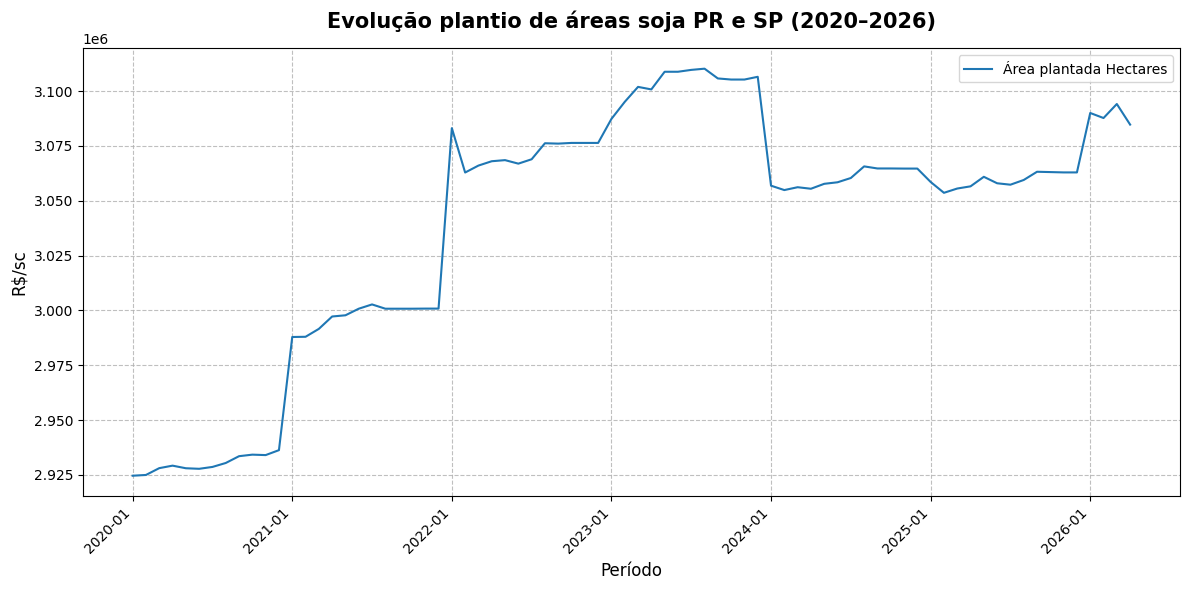

In [98]:
#Totalizando por area plantada e colhida por Data
df_mensal = (df_producao_parana
    .groupby('data')[['area_plantada_hect', 'producao_toneladas']]
    .mean()
    .round(2)
    .reset_index()
)

# Convertendo para string para o matplotlib
df_mensal['ano_mes_str'] = df_mensal['data'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_mensal, x='ano_mes_str', y='area_plantada_hect', linewidth=1.5, label='Área plantada Hectares')

# Mostrando por ano o eixo X
ticks = df_mensal['ano_mes_str'][::12] 
plt.xticks(ticks=range(0, len(df_mensal), 12), labels=ticks, rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.8, linewidth=0.8)

plt.title('Evolução plantio de áreas soja PR e SP (2020–2026)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Período', fontsize=12)
plt.ylabel('R$/sc', fontsize=12)
plt.tight_layout()

plt.show()